# RSI vs Stochastic Oscillator Calculation and Plot Notebook
- Created By: Luke Welch
- Date: 04/24/2025
- Traders@SMU L2 Project 4

## 1. RSI Calculation and Plot

In [1]:
#Enter stock ticker
Ticker = 'AAPL' 
Start = '2024-01-01'#YYYY-MM-DD
End = '2025-01-01'
Interval='1d'
# Thresholds for oversold and overbought regions
oversold = 30
overbought = 70

In [2]:
import yfinance as yf
import talib as ta
import numpy as np
import matplotlib.pyplot as plt
data = yf.download(Ticker, start=Start, end=End, interval=Interval)

# Calculate RSI and add it to our dataframe
data['RSI'] = ta.RSI(data['Close'].values.ravel(), timeperiod=14)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
#Generate Buy and Sell Signals

# Inputs (pandas Series of same length)
rsi = data['RSI']         # Your RSI values
price = data['Close']     # Corresponding stock prices

# Initialize empty signal arrays
buy_rsi = []
sell_rsi = []
buy_price = []
sell_price = []

# Loop through the data
for i in range(1, len(rsi)):
    # If either RSI or price is NaN, skip this point
    if np.isnan(rsi.iloc[i]) or np.isnan(rsi.iloc[i - 1]):
        buy_rsi.append(np.nan)
        sell_rsi.append(np.nan)
        buy_price.append(np.nan)
        sell_price.append(np.nan)
        continue

    # BUY: RSI crosses above oversold threshold
    if rsi.iloc[i - 1] < oversold and rsi.iloc[i] >= oversold:
        buy_rsi.append(rsi.iloc[i])
        sell_rsi.append(np.nan)
        buy_price.append(price.iloc[i])
        sell_price.append(np.nan)

    # SELL: RSI crosses below overbought threshold
    elif rsi.iloc[i - 1] > overbought and rsi.iloc[i] <= overbought:
        buy_rsi.append(np.nan)
        sell_rsi.append(rsi.iloc[i])
        buy_price.append(np.nan)
        sell_price.append(price.iloc[i])

    else:
        buy_rsi.append(np.nan)
        sell_rsi.append(np.nan)
        buy_price.append(np.nan)
        sell_price.append(np.nan)

def safe_to_float(val):
    try:
        # If val is already np.nan, this will return np.nan safely
        return float(val)
    except (TypeError, ValueError):
        return np.nan

buy_price = [safe_to_float(x) for x in buy_price]
sell_price = [safe_to_float(x) for x in sell_price]

buy_price = np.array(buy_price, dtype=np.float64)
sell_price = np.array(sell_price, dtype=np.float64)

/var/folders/w5/h50cdbzx4fl6ylfv17qcwkbw0000gn/T/ipykernel_18335/2108890512.py:46: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(val)


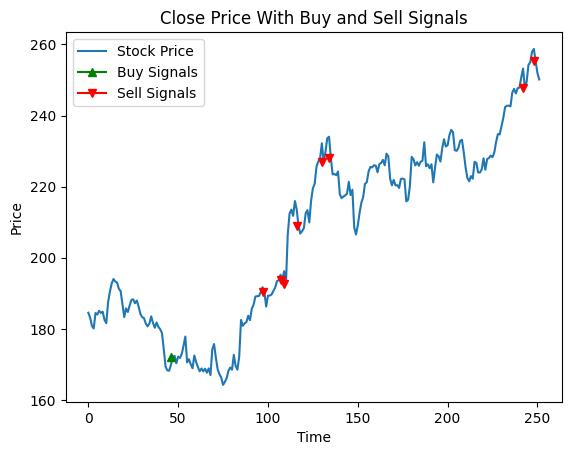

In [6]:
#Make a Nice, Beautiful, Amazing plot
x = np.arange(0, len(data['Close']), 1)
plt.plot(x, data['Close'], label='Stock Price')
plt.plot(buy_price, marker='^', color = 'green', label='Buy Signals')
plt.plot(sell_price, marker='v', color = 'red', label='Sell Signals')
plt.legend()
plt.title('Close Price With Buy and Sell Signals')
plt.ylabel('Price')
plt.xlabel('Time')
plt.show()

## 2. Stochastic Oscillator Calculation and Plot

In [10]:
#Enter stock ticker
Ticker = 'AAPL' 
Start = '2024-01-01'#YYYY-MM-DD
End = '2025-01-01'
Interval='1d'
oversold_region = 20 #Define what counts as oversold
overbought_region = 80 #Define what counts as overbought

In [12]:
import yfinance as yf
import talib as ta
import numpy as np
import matplotlib.pyplot as plt
data = yf.download(Ticker, start=Start, end=End, interval=Interval)

# Compute the stochastic oscillator
slowk, slowd = ta.STOCH(data['High'].values.ravel(), data['Low'].values.ravel(), data['Close'].values.ravel(), fastk_period=14)

# Add to DataFrame for inspection or plotting
data['SlowK'] = slowk
data['SlowD'] = slowd

[*********************100%***********************]  1 of 1 completed


In [13]:
close = np.array(data['Close'])
buy_signals_RSI = []
sell_signals_RSI = []
buy_signals_close = []
sell_signals_close = []

# Loop through slowk and slowd values
for i in range(0, len(slowk)):
    # Skip if NaN values (can happen early on)
    if np.isnan(slowk[i]) or np.isnan(slowd[i]):
        buy_signals_RSI.append(np.nan)
        buy_signals_close.append(np.nan)
        sell_signals_RSI.append(np.nan)
        sell_signals_close.append(np.nan)
        continue

    # BUY signal: slowk crosses above slowd in oversold region
    if slowk[i - 1] < slowd[i - 1] and slowk[i] > slowd[i] and slowk[i] < oversold_region and slowd[i] < oversold_region:
        buy_signals_RSI.append(slowk[i])
        sell_signals_RSI.append(np.nan)
        buy_signals_close.append(close[i])
        sell_signals_close.append(np.nan)

    # SELL signal: slowk crosses below slowd in overbought region
    elif slowk[i - 1] > slowd[i - 1] and slowk[i] < slowd[i] and slowk[i] > overbought_region and slowd[i] > overbought_region:
        sell_signals_RSI.append(slowk[i])
        buy_signals_RSI.append(np.nan)
        sell_signals_close.append(close[i])
        buy_signals_close.append(np.nan)

    else:
        # No signal
        buy_signals_RSI.append(np.nan)
        sell_signals_RSI.append(np.nan)
        buy_signals_close.append(np.nan)
        sell_signals_close.append(np.nan)

def safe_to_float(val):
    try:
        # If val is already np.nan, this will return np.nan safely
        return float(val)
    except (TypeError, ValueError):
        return np.nan

buy_signals_close = [safe_to_float(x) for x in buy_signals_close]
sell_signals_close = [safe_to_float(x) for x in sell_signals_close]

buy_signals_close = np.array(buy_signals_close, dtype=np.float64)
sell_signals_close = np.array(sell_signals_close, dtype=np.float64)

/var/folders/w5/h50cdbzx4fl6ylfv17qcwkbw0000gn/T/ipykernel_18335/3422689067.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(val)


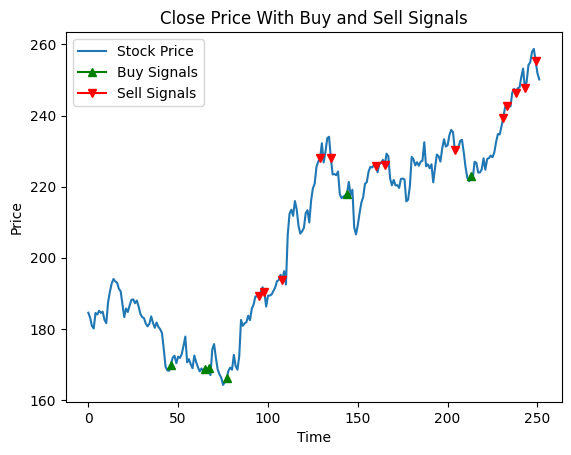

In [15]:
y = np.arange(0, len(data['Close']), 1)
plt.plot(y, data['Close'], label='Stock Price')
plt.plot(buy_signals_close, marker='^', color = 'green', label='Buy Signals')
plt.plot(sell_signals_close, marker='v', color = 'red', label= 'Sell Signals')
plt.legend()
plt.title('Close Price With Buy and Sell Signals')
plt.ylabel('Price')
plt.xlabel('Time')
plt.show()